C:\Users\igore\AppData\Local\Temp\ipykernel_29304\4047391552.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x='db', y='total', palette=palette)


,db,total
18,Oracle,176747808
16,MySQL,56969091
13,MSSQL,10899342
17,Neo4j,6382436
20,Postgress,3205013
23,ScyllaDB,2968727
15,MongoDB,2907916
11,Hypertable,2885418
25,нереляционные,2883531
12,InfiniteGraph,2881860


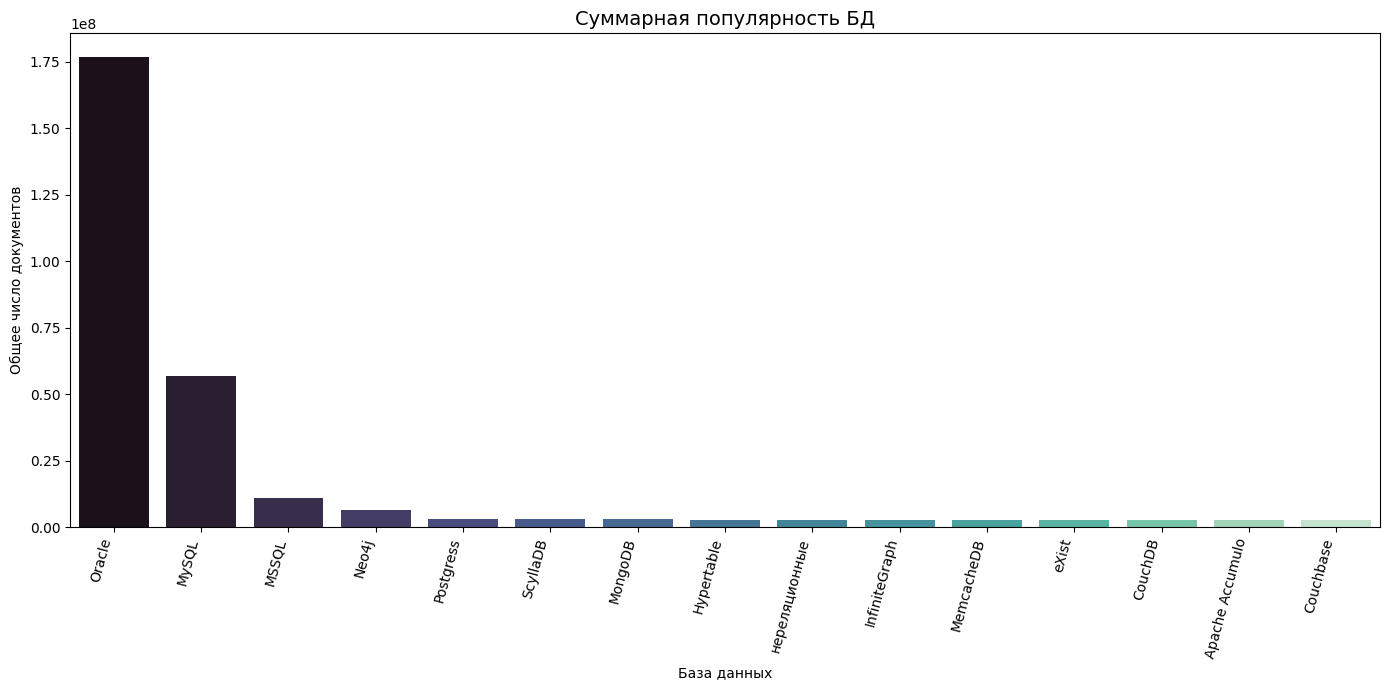

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

yandex_total_df = pd.read_csv('data/yandex_total.csv')
brave_total_df = pd.read_csv('data/brave_total.csv')
yandex_scored_df = pd.read_csv('data/yandex_scored.csv')
brave_scored_df = pd.read_csv('data/brave_scored.csv')


def plot_combined_db_popularity(
    dfs: list[pd.DataFrame],
    title='Суммарная популярность БД',
    top_n=None,
    sort_desc=True,
    figsize=(14, 7),
    palette='mako'
):
    frames = []

    for df in dfs:
        data = df.copy()

        first_col = data.columns[0]
        if str(first_col).startswith('Unnamed') or str(first_col) == '':
            data = data.iloc[:, 1:]

        if 'db' not in data.columns or 'total' not in data.columns:
            raise ValueError("Каждый DataFrame должен содержать столбцы 'db' и 'total'")

        data = data[['db', 'total']].copy()
        data['db'] = data['db'].astype(str).str.strip()
        data['total'] = pd.to_numeric(data['total'], errors='coerce')
        data = data.dropna(subset=['db', 'total'])

        frames.append(data)

    result = pd.concat(frames, ignore_index=True)
    result = result.groupby('db', as_index=False)['total'].sum()

    if sort_desc:
        result = result.sort_values('total', ascending=False)
    else:
        result = result.sort_values('total', ascending=True)

    if top_n is not None:
        result = result.head(top_n)

    plt.figure(figsize=figsize)
    sns.barplot(data=result, x='db', y='total', palette=palette)
    
    

    plt.title(title, fontsize=14)
    plt.xlabel('База данных')
    plt.ylabel('Общее число документов')
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()


    return result




plot_combined_db_popularity(
    [yandex_total_df, brave_total_df],
    title='Суммарная популярность БД',
    top_n=15
)

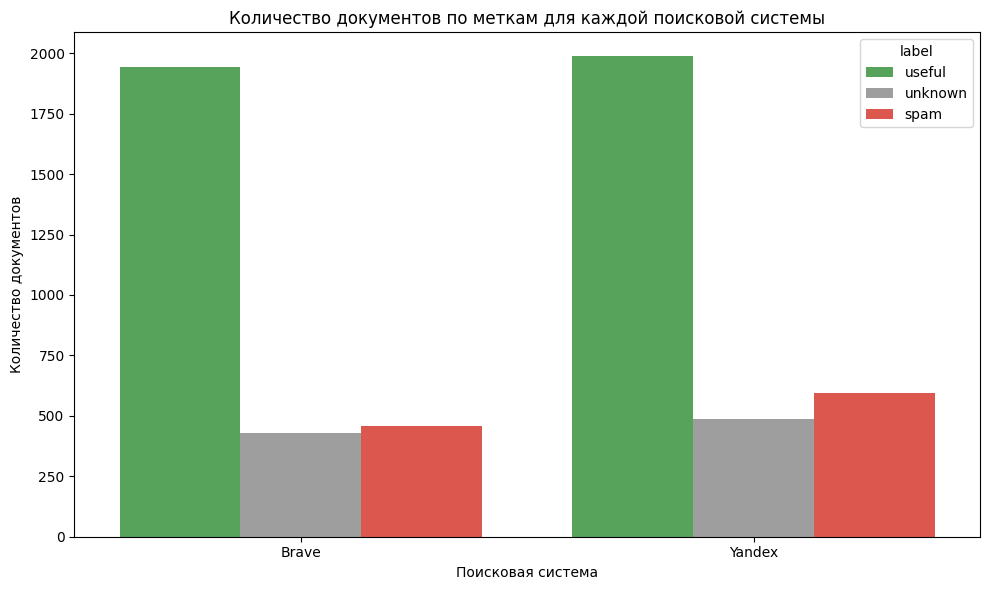

In [4]:
def plot_label_counts(brave_df: pd.DataFrame, yandex_df: pd.DataFrame):
    order_labels = ['useful', 'unknown', 'spam']

    brave_counts = (
        brave_df['label']
        .value_counts()
        .reindex(order_labels, fill_value=0)
        .reset_index()
    )
    brave_counts.columns = ['label', 'count']
    brave_counts['search_engine'] = 'Brave'

    yandex_counts = (
        yandex_df['label']
        .value_counts()
        .reindex(order_labels, fill_value=0)
        .reset_index()
    )
    yandex_counts.columns = ['label', 'count']
    yandex_counts['search_engine'] = 'Yandex'

    plot_df = pd.concat([brave_counts, yandex_counts], ignore_index=True)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=plot_df,
        x='search_engine',
        y='count',
        hue='label',
        hue_order=order_labels,
        palette={
            'useful': '#4CAF50',
            'unknown': '#9E9E9E',
            'spam': '#F44336'
        }
    )

    plt.title('Количество документов по меткам для каждой поисковой системы')
    plt.xlabel('Поисковая система')
    plt.ylabel('Количество документов')
    plt.legend(title='label')
    plt.tight_layout()
    
plot_label_counts(brave_scored_df, yandex_scored_df)